fit random forest with (almost) all variables and use it for feature selection. 

In [1]:
import pandas as pd
import numpy as np
#from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix #plot_confusion_matrix, 
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt


In [2]:
#read data and drop columns that would generate too many dummy variables in the one-hot encoding
dat = pd.read_parquet('data/votersurvey_cleaned_noDropNA.parquet')
dat = dat.dropna()
dat = dat.drop(columns = "inputstate_2016") #creates too many dummy variables


#prepare data
y = dat["presvote16post_2016"]
X = dat.drop(columns = "presvote16post_2016")
#one-hot encode categorical data
X_oh = pd.get_dummies(X, dtype = int)
X_train_oh, X_test_oh, y_train, y_test = train_test_split(X_oh, y, test_size=0.2, random_state=431)

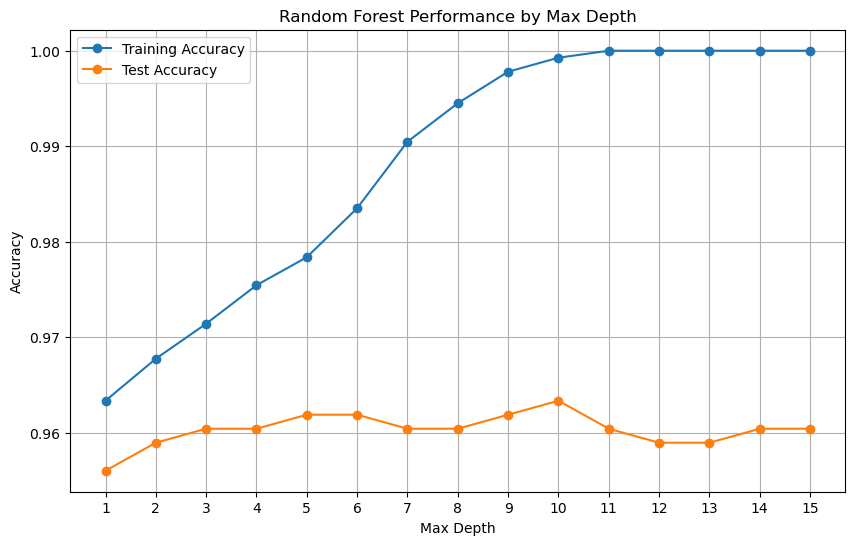

<Figure size 640x480 with 0 Axes>

In [5]:
# test RF performance by max depth

# Initialize lists to store results
depths = list(range(1, 16))
train_accuracies = []
test_accuracies = []

# Run Random Forest for each depth
for i in depths:
    rf = RandomForestClassifier(
        n_estimators=500,
        random_state=123,
        max_depth=i,
        #max_features = 20
    )
    rf.fit(X_train_oh, y_train)

    # Store accuracies
    train_acc = rf.score(X_train_oh, y_train)
    test_acc = rf.score(X_test_oh, y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Create DataFrame for plotting
results_df = pd.DataFrame({
    'max_depth': depths,
    'train_accuracy': train_accuracies,
    'test_accuracy': test_accuracies
})

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(results_df['max_depth'], results_df['train_accuracy'],
         marker='o', label='Training Accuracy')
plt.plot(results_df['max_depth'], results_df['test_accuracy'],
         marker='o', label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Random Forest Performance by Max Depth')
plt.legend()
plt.grid(True)
plt.xticks(depths)
plt.show()

#save figure
plt.savefig('results/RF/RF_performance_by_maxdepth_clinton_trump.png')

# Display the DataFrame
#print("\nResults DataFrame:")
#print(results_df)

In [6]:
"""
#attempt with limiting max_features
#don't use
rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = 6, max_features = 10)
rf.fit(X_train_oh, y_train)

print(f"Train accuracy depth 6: ", rf.score(X_train_oh, y_train))
print(f"Test accuracy depth 6", rf.score(X_test_oh, y_test))
"""

'\n#attempt with limiting max_features\n#don\'t use\nrf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = 6, max_features = 10)\nrf.fit(X_train_oh, y_train)\n\nprint(f"Train accuracy depth 6: ", rf.score(X_train_oh, y_train))\nprint(f"Test accuracy depth 6", rf.score(X_test_oh, y_test))\n'

                 precision    recall  f1-score   support

   Donald Trump       0.97      0.95      0.96       351
Hillary Clinton       0.95      0.97      0.96       331

       accuracy                           0.96       682
      macro avg       0.96      0.96      0.96       682
   weighted avg       0.96      0.96      0.96       682



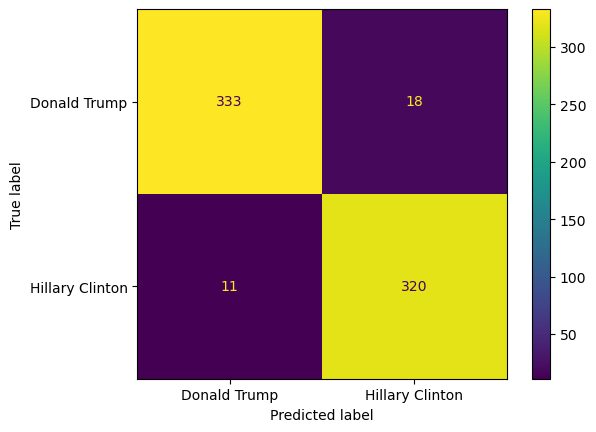

In [7]:
#choose selected maxdepth
selectedmaxdepth = 5 #no significant increase in test accuracy afterwards

# run random forest with prefered depth and create confusion matrix
rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = selectedmaxdepth)
rf.fit(X_train_oh, y_train)

y_pred = rf.predict(X_test_oh)
cmat = confusion_matrix(y_test, y_pred, labels = rf.classes_)
ConfusionMatrixDisplay(cmat, display_labels = rf.classes_).plot()

#save confmat figure
plt.savefig(f'results/RF/RF_confmat_maxdepth{selectedmaxdepth}.png')

#classification report
print(classification_report(y_test, y_pred))

### extract feature importances
based on the random forest with chosen max depth
- method 1: using mean decrease in gini impurities
- method 2: using feature permutation. I believe this is the better approach since we have high-cardinality features

#### feature importance using mean decrease in gini impurities

In [8]:
#extract feature importance and regroup by dummy variable
#e. g. sum over the rows "presvote16post_2016_Hillary Clinton" and "presvote16post_2016_Donald Trump"

#this can be used for feature selection


#create df
imp = rf.feature_importances_
imp_names = rf.feature_names_in_
imp_df = pd.DataFrame({"imp" : imp, "imp_names" : imp_names})

# Extract the base name (everything before the last underscore)
imp_df["base_name"] = imp_df["imp_names"].str.rsplit('_', n=1).str[0]

# Group by base_name and sum the 'imp' values
imp_df_grouped = imp_df.groupby("base_name", as_index=False)["imp"].sum().sort_values("imp", ascending = False)
imp_df_grouped = imp_df_grouped.rename(columns = {"imp": "imp_grouped"})

imp_df_grouped.head(25)

,base_name,imp_grouped
69,healthreformbill_2016,0.113351
108,obamaapp_2016,0.088921
149,univhealthcov_2016,0.075154
118,policies_favor_2016,0.053467
158,wealth_2016,0.045785
66,gvmt_involment_2016,0.043478
38,envwarm_2016,0.042575
119,pp_primary16_2016,0.041328
117,police_threat_2016,0.038893
115,pid3_2016,0.037000


In [9]:
#individual feature importances for comparison
imp_df.sort_values("imp", ascending = False).head(25)

,imp,imp_names,base_name
250,0.064524,healthreformbill_2016_Repealed,healthreformbill_2016
44,0.059695,obamaapp_2016_Strongly Disapprove,obamaapp_2016
248,0.047512,healthreformbill_2016_Expanded,healthreformbill_2016
251,0.039896,envwarm_2016_Definitely is happening,envwarm_2016
245,0.039486,univhealthcov_2016_No,univhealthcov_2016
246,0.035537,univhealthcov_2016_Yes,univhealthcov_2016
9,0.034581,ft_blm_2016,ft_blm
265,0.033210,govt_reg_2016_Too much,govt_reg_2016
406,0.030520,policies_favor_2016_Favor blacks over whites,policies_favor_2016
90,0.029520,wealth_2016_Should be more evenly distributed,wealth_2016


#### fit random forest using the feature selection based on gini impurity

In [10]:
selectedfeatures_gini = imp_df_grouped['base_name'].head(25)
selectedfeatures_gini

69      healthreformbill_2016
108             obamaapp_2016
149        univhealthcov_2016
118       policies_favor_2016
158               wealth_2016
66        gvmt_involment_2016
38               envwarm_2016
119         pp_primary16_2016
117        police_threat_2016
115                 pid3_2016
64              govt_reg_2016
49                     ft_blm
95     immi_contribution_2016
83               imiss_l_2016
17         affirmact_gen_2016
97           immi_muslim_2016
152     view_transgender_2016
116                 pid7_2016
143              taxdoug_2016
6        RIGGED_SYSTEM_4_2016
51                     ft_fem
98       immi_naturalize_2016
5        RIGGED_SYSTEM_3_2016
75               imiss_d_2016
137              sexism2_2016
Name: base_name, dtype: str

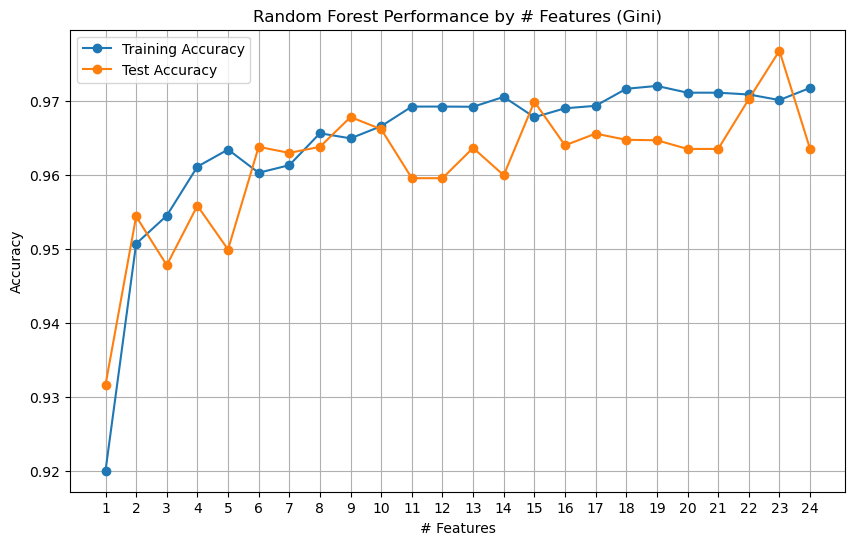

In [11]:
#refit RF with different numbers of selected features

#initialize variables for the loop
featurecount = list(range(1, 25))
train_accuracies = []
test_accuracies = []

#loop over varying numbers of features
for i in featurecount:
    #read inital df each time and drop rows after selecting variables
    dat_fs = pd.read_parquet('data/votersurvey_cleaned_noDropNA.parquet') 
    featurestokeep = selectedfeatures_gini[0:i].copy()
    featurestokeep.loc['1'] = 'presvote16post_2016' #add target variable to selected features
    dat_fs = dat_fs.filter(items=featurestokeep) #filter for only selected variables
    dat_fs = dat_fs.dropna()
    
    #prepare data
    y = dat_fs["presvote16post_2016"]
    X = dat_fs.drop(columns = "presvote16post_2016")
    #one-hot encode categorical data
    X_oh = pd.get_dummies(X, dtype = int)
    X_train_oh, X_test_oh, y_train, y_test = train_test_split(X_oh, y, test_size=0.2, random_state=431)


    #fit rf
    rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = selectedmaxdepth)
    rf.fit(X_train_oh, y_train)


    # Store accuracies
    train_acc = rf.score(X_train_oh, y_train)
    test_acc = rf.score(X_test_oh, y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Create DataFrame for plotting
results_df = pd.DataFrame({
    '# Features': featurecount,
    'train_accuracy': train_accuracies,
    'test_accuracy': test_accuracies
})

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(results_df['# Features'], results_df['train_accuracy'],
         marker='o', label='Training Accuracy')
plt.plot(results_df['# Features'], results_df['test_accuracy'],
         marker='o', label='Test Accuracy')
plt.xlabel('# Features')
plt.ylabel('Accuracy')
plt.title('Random Forest Performance by # Features (Gini)')
plt.legend()
plt.grid(True)
plt.xticks(featurecount)
#save figure
plt.savefig(f'results/RF/RF_performance_by_number_of_features_gini_maxdepth{selectedmaxdepth}.png')
plt.show()


    

#### feature importance using permutation importance

In [12]:
#feature importance based on permutation importance
#this takes a few minutes to run

from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf, X_test_oh, y_test, random_state=42, n_jobs=-1
)

In [13]:
#create df
imp = result.importances_mean
imp_names = rf.feature_names_in_
permutation_importances = pd.DataFrame({"imp_names" : imp_names, "imp" : imp})

# Extract the base name (everything before the last underscore)
permutation_importances["base_name"] = permutation_importances["imp_names"].str.rsplit('_', n=1).str[0]

# Group by base_name and sum the 'imp' values
permutation_importances_grouped = permutation_importances.groupby("base_name", as_index=False)["imp"].sum().sort_values("imp", ascending = False)
permutation_importances_grouped = permutation_importances_grouped.rename(columns = {"imp": "imp_grouped"})

#display grouped permutation importances
permutation_importances_grouped.head(25)

,base_name,imp_grouped
12,obamaapp_2016,0.007112
16,policies_favor_2016,0.003643
17,pp_primary16_2016,0.001214
13,pid3_2016,0.001041
1,RIGGED_SYSTEM_4_2016,0.000867
4,govt_reg_2016,0.000867
11,immi_naturalize_2016,0.000694
18,taxdoug_2016,0.000520
20,view_transgender_2016,0.000173
19,univhealthcov_2016,0.000173


In [14]:
#display individual permutaiton importances
permutation_importances.sort_values('imp', ascending = False).head(25)

,imp_names,imp,base_name
8,obamaapp_2016_Strongly Disapprove,0.003816,obamaapp_2016
13,policies_favor_2016_Favor blacks over whites,0.002949,policies_favor_2016
6,obamaapp_2016_Somewhat Disapprove,0.002082,obamaapp_2016
27,pp_primary16_2016_In the Democratic primary,0.001214,pp_primary16_2016
34,pid3_2016_Democrat,0.001041,pid3_2016
5,obamaapp_2016_Somewhat Approve,0.001041,obamaapp_2016
74,RIGGED_SYSTEM_4_2016_Disagree,0.000867,RIGGED_SYSTEM_4_2016
40,govt_reg_2016_Don't know,0.000867,govt_reg_2016
15,policies_favor_2016_Treat both groups the same,0.000694,policies_favor_2016
45,immi_contribution_2016_Mostly make a contribution,0.000694,immi_contribution_2016


#### fit random forest using the feature selection based on permutation importances

In [15]:
#isolate top 25 features
selectedfeatures_perm = permutation_importances_grouped['base_name'].head(25)
selectedfeatures_perm

12             obamaapp_2016
16       policies_favor_2016
17         pp_primary16_2016
13                 pid3_2016
1       RIGGED_SYSTEM_4_2016
4              govt_reg_2016
11      immi_naturalize_2016
18              taxdoug_2016
20     view_transgender_2016
19        univhealthcov_2016
21               wealth_2016
0       RIGGED_SYSTEM_3_2016
9     immi_contribution_2016
10          immi_muslim_2016
7               imiss_d_2016
5        gvmt_involment_2016
3               envwarm_2016
14                 pid7_2016
8               imiss_l_2016
15        police_threat_2016
2         affirmact_gen_2016
6      healthreformbill_2016
Name: base_name, dtype: str

In [16]:
"""
#this block goes in the loop below
dat_fs = pd.read_parquet('data/votersurvey_cleaned_noDropNA.parquet') #reload initial dataframe
featurestokeep = selectedfeatures_perm.copy()
featurestokeep.loc['1'] = 'presvote16post_2016' #add target variable to selected features
dat_fs = dat_fs.filter(items=featurestokeep)
dat_fs = dat_fs.dropna()

#prepare data
y = dat_fs["presvote16post_2016"]
X = dat_fs.drop(columns = "presvote16post_2016")
#one-hot encode categorical data
X_oh = pd.get_dummies(X, dtype = int)
X_train_oh, X_test_oh, y_train, y_test = train_test_split(X_oh, y, test_size=0.2, random_state=431)
"""

'\n#this block goes in the loop below\ndat_fs = pd.read_parquet(\'data/votersurvey_cleaned_noDropNA.parquet\') #reload initial dataframe\nfeaturestokeep = selectedfeatures_perm.copy()\nfeaturestokeep.loc[\'1\'] = \'presvote16post_2016\' #add target variable to selected features\ndat_fs = dat_fs.filter(items=featurestokeep)\ndat_fs = dat_fs.dropna()\n\n#prepare data\ny = dat_fs["presvote16post_2016"]\nX = dat_fs.drop(columns = "presvote16post_2016")\n#one-hot encode categorical data\nX_oh = pd.get_dummies(X, dtype = int)\nX_train_oh, X_test_oh, y_train, y_test = train_test_split(X_oh, y, test_size=0.2, random_state=431)\n'

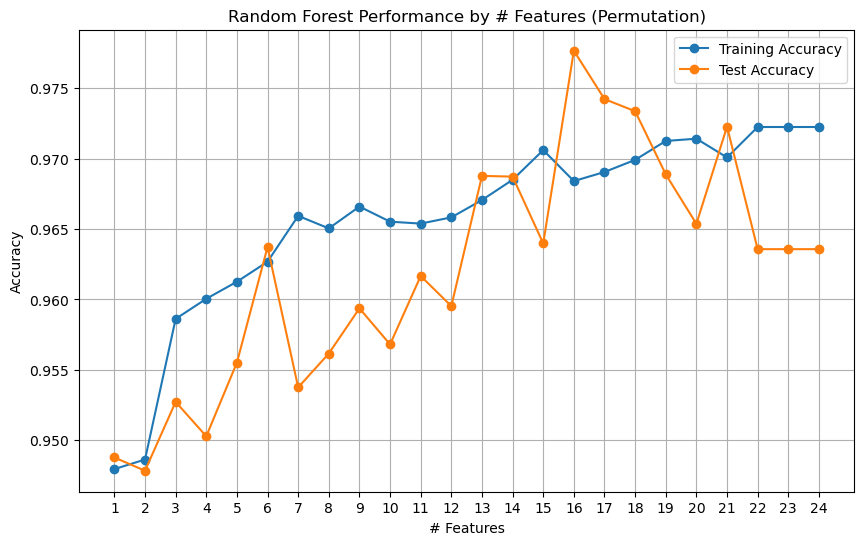

In [17]:
#refit RF with different numbers of selected features

#initialize variables for the loop
featurecount = list(range(1, 25))
train_accuracies = []
test_accuracies = []

#loop over varying numbers of features
for i in featurecount:
    #read inital df each time and drop rows after selecting variables
    dat_fs = pd.read_parquet('data/votersurvey_cleaned_noDropNA.parquet') 
    featurestokeep = selectedfeatures_perm[0:i].copy()
    featurestokeep.loc['1'] = 'presvote16post_2016' #add target variable to selected features
    dat_fs = dat_fs.filter(items=featurestokeep) #filter for only selected variables
    dat_fs = dat_fs.dropna()
    
    #prepare data
    y = dat_fs["presvote16post_2016"]
    X = dat_fs.drop(columns = "presvote16post_2016")
    #one-hot encode categorical data
    X_oh = pd.get_dummies(X, dtype = int)
    X_train_oh, X_test_oh, y_train, y_test = train_test_split(X_oh, y, test_size=0.2, random_state=431)


    #fit rf
    rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = selectedmaxdepth)
    rf.fit(X_train_oh, y_train)


    # Store accuracies
    train_acc = rf.score(X_train_oh, y_train)
    test_acc = rf.score(X_test_oh, y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Create DataFrame for plotting
results_df = pd.DataFrame({
    '# Features': featurecount,
    'train_accuracy': train_accuracies,
    'test_accuracy': test_accuracies
})

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(results_df['# Features'], results_df['train_accuracy'],
         marker='o', label='Training Accuracy')
plt.plot(results_df['# Features'], results_df['test_accuracy'],
         marker='o', label='Test Accuracy')
plt.xlabel('# Features')
plt.ylabel('Accuracy')
plt.title('Random Forest Performance by # Features (Permutation)')
plt.legend()
plt.grid(True)
plt.xticks(featurecount)
#save figure
plt.savefig(f'results/RF/RF_performance_by_number_of_features_permutation_maxdepth{selectedmaxdepth}.png')
plt.show()


    